In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

churn_data = pd.read_csv('telco_churn_data.csv')

In [2]:
# Define features (X) and target variable (y)
X = churn_data.drop(columns=['Customer Status'])  # Features
y = churn_data['Customer Status']  # Target

# Split into train (80%) and test (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standardize numeric features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [3]:
# Logistic Regression Model
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print("\nLogistic Regression Classification Report:\n", classification_report(y_test, y_pred_log))

Logistic Regression Accuracy: 0.8147622427253371

Logistic Regression Classification Report:
               precision    recall  f1-score   support

           0       0.66      0.70      0.68        91
           1       0.90      0.88      0.89       944
           2       0.66      0.67      0.66       374

    accuracy                           0.81      1409
   macro avg       0.74      0.75      0.74      1409
weighted avg       0.82      0.81      0.82      1409



In [4]:
# Random Forest Model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
print("\nRandom Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nRandom Forest Classification Report:\n", classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 0.8396025550035486

Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.67      0.69        91
           1       0.88      0.95      0.91       944
           2       0.75      0.60      0.66       374

    accuracy                           0.84      1409
   macro avg       0.78      0.74      0.76      1409
weighted avg       0.83      0.84      0.83      1409



In [5]:
# XGBoost Model (Fixed Warning Issue)
xgb_model = XGBClassifier(objective="multi:softmax", eval_metric="mlogloss", random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
print("\nXGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("\nXGBoost Classification Report:\n", classification_report(y_test, y_pred_xgb))


XGBoost Accuracy: 0.8502484031227822

XGBoost Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.66      0.70        91
           1       0.90      0.93      0.92       944
           2       0.73      0.69      0.71       374

    accuracy                           0.85      1409
   macro avg       0.79      0.76      0.77      1409
weighted avg       0.85      0.85      0.85      1409



In [6]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report

# Naive Bayes Model
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)
print("\nNaive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print("\nNaive Bayes Classification Report:\n", classification_report(y_test, y_pred_nb))


Naive Bayes Accuracy: 0.6799148332150461

Naive Bayes Classification Report:
               precision    recall  f1-score   support

           0       0.28      1.00      0.44        91
           1       0.91      0.76      0.83       944
           2       0.50      0.40      0.44       374

    accuracy                           0.68      1409
   macro avg       0.56      0.72      0.57      1409
weighted avg       0.76      0.68      0.70      1409



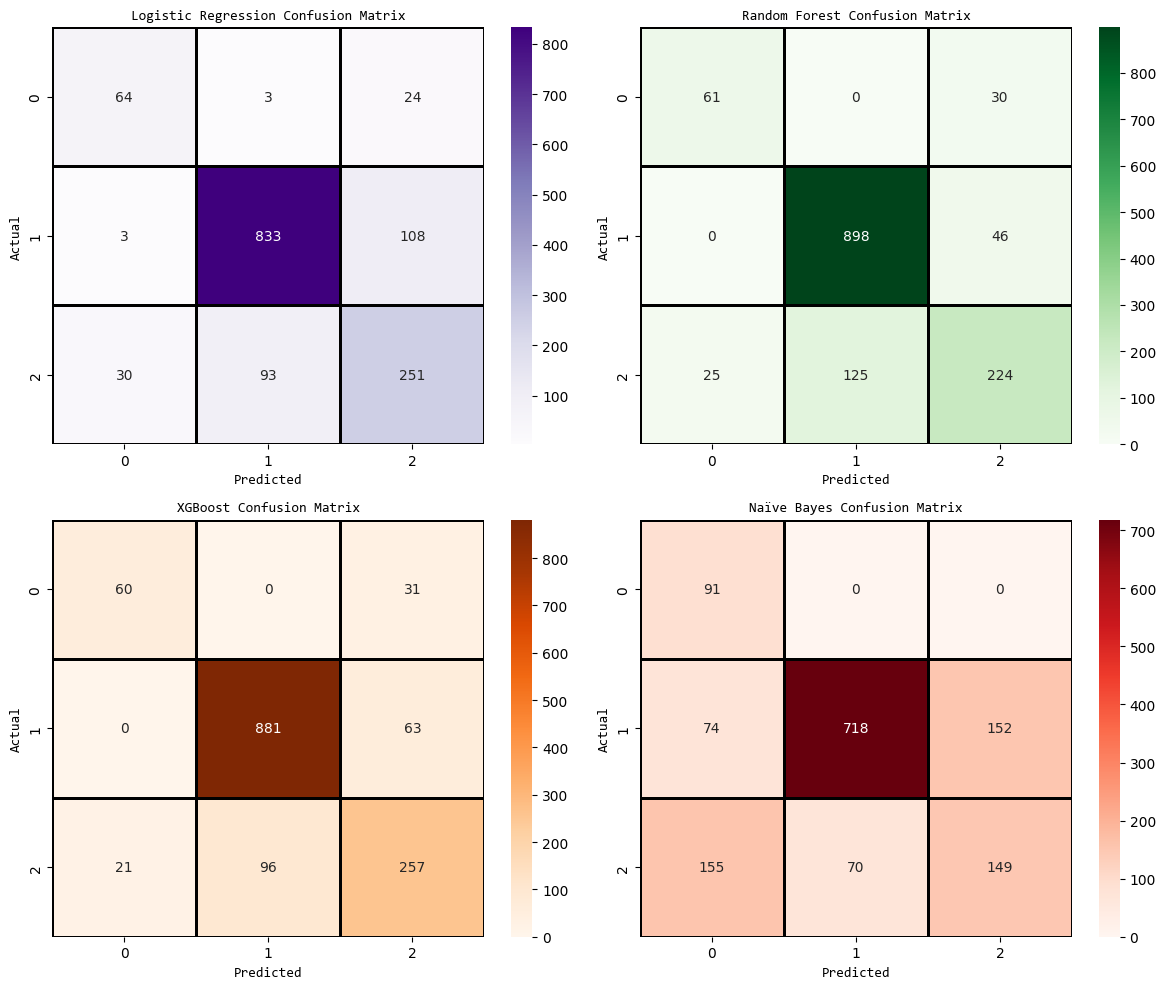

In [7]:
from sklearn.metrics import confusion_matrix

# Define custom color maps for each model
color_maps = {
    "Logistic Regression": "Purples",
    "Random Forest": "Greens",
    "XGBoost": "Oranges",
    "Naïve Bayes": "Reds"
}

# Function to plot multiple confusion matrices in a grid
def plot_confusion_matrices(models, y_true, y_preds, nrows=2, ncols=2):
    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 10))
    axes = axes.flatten()  # Flatten for easy iteration

    for idx, (model_name, y_pred) in enumerate(zip(models.keys(), y_preds)):
        cm = confusion_matrix(y_true, y_pred)
        sns.heatmap(
            cm, annot=True, fmt="d", cmap=color_maps[model_name], 
            xticklabels=np.unique(y_true), yticklabels=np.unique(y_true),
            linewidths=1, linecolor="black", ax=axes[idx]
        )
        axes[idx].set_xlabel("Predicted", fontsize=10, fontfamily="Consolas")
        axes[idx].set_ylabel("Actual", fontsize=10, fontfamily="Consolas")
        axes[idx].set_title(f"{model_name} Confusion Matrix", fontsize=10, fontfamily="Consolas")

    plt.tight_layout()  # Adjust layout for better fit
    plt.show()

# Define models and their predictions
models = {
    "Logistic Regression": y_pred_log,
    "Random Forest": y_pred_rf,
    "XGBoost": y_pred_xgb,
    "Naïve Bayes": y_pred_nb
}

# Plot the confusion matrices in a 2x2 grid
plot_confusion_matrices(models, y_test, list(models.values()))


In [8]:
# Get feature importances
rf_importance = rf_model.feature_importances_
xgb_importance = xgb_model.feature_importances_

# Convert to DataFrame
feature_names = X.columns
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Random Forest Importance": rf_importance,
    "XGBoost Importance": xgb_importance
})

# Sort by importance
importance_df = importance_df.sort_values(by="XGBoost Importance", ascending=False)